

# Week 6 - Data Transformation

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [18]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

### Source Data

In [19]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (Customer Churn)/data/data_train_20240224.csv')

In [20]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Attrition_Flag          4050 non-null   int64 
 1   Customer_Age            4050 non-null   int64 
 2   Dependent_count         4050 non-null   int64 
 3   Months_Inactive_12_mon  4050 non-null   int64 
 4   Total_Trans_Amt         4050 non-null   int64 
 5   Education_Level         4050 non-null   object
dtypes: int64(5), object(1)
memory usage: 190.0+ KB


In [21]:
#### Shape
pdf.shape

(4050, 6)

In [22]:
#### Null
pdf.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Dependent_count,0
Months_Inactive_12_mon,0
Total_Trans_Amt,0
Education_Level,0


In [23]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [24]:
#### First 5 rows
pdf.head()

,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Total_Trans_Amt,Education_Level
0,0,60,1,2,4183,High School
1,0,48,4,1,3843,Graduate
2,1,40,3,2,781,Graduate
3,0,34,1,6,4314,Graduate
4,0,32,1,2,2439,High School


### Numeric features

In [25]:
#### Get descriptive statistics
pdf.describe()


,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Total_Trans_Amt
count,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000
mean,0.161975,46.218272,2.328889,2.346173,4465.793827
std,0.368474,8.002146,1.289040,1.008321,3459.350086
min,0.000000,26.000000,0.000000,0.000000,563.000000
25%,0.000000,41.000000,1.000000,2.000000,2199.500000
50%,0.000000,46.000000,2.000000,2.000000,3913.500000
75%,0.000000,52.000000,3.000000,3.000000,4729.750000
max,1.000000,66.000000,5.000000,6.000000,18484.000000


### Target feature

In [26]:
#### Count Attrition_Flag by value
pdf.Attrition_Flag.value_counts()


,count
Attrition_Flag,
0,3394
1,656


In [27]:
#### Plot Attrition_Flag bar graph

## Data Preparation

In [28]:
data = pdf.copy()

In [29]:
# Separate target variable and features
y = data['Attrition_Flag']
X = data.drop(['Attrition_Flag'], axis=1)

In [30]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

array([[<Axes: title={'center': 'Customer_Age'}>]], dtype=object)

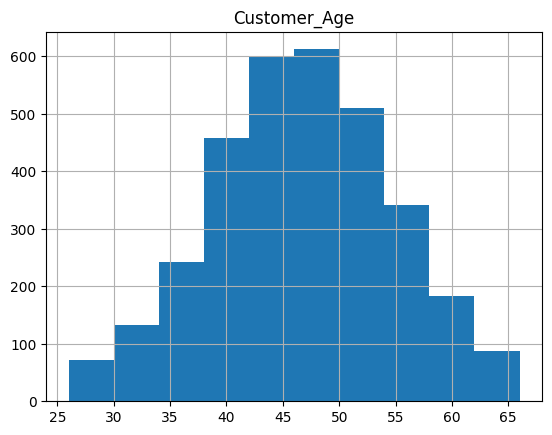

In [31]:
# Plot Customer_Age histogram
X_train[['Customer_Age']].hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

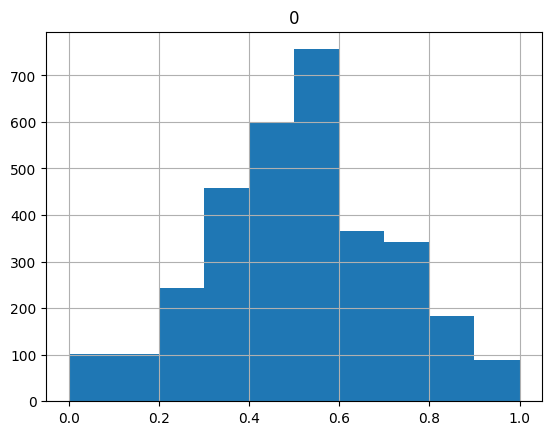

In [32]:
# Apply Customer_Age minmax scaling
results = MinMaxScaler().fit_transform(X_train[['Customer_Age']])

# Plot preprocessed Customer_Age histogram
pd.DataFrame(results).hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

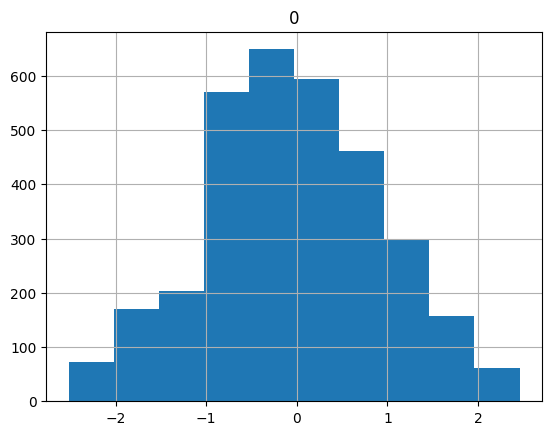

In [33]:
# Apply Customer_Age standard scaling
results = StandardScaler().fit_transform(X_train[['Customer_Age']])

# Plot preprocessed Customer_Age histogram
pd.DataFrame(results).hist()

<Axes: ylabel='Education_Level'>

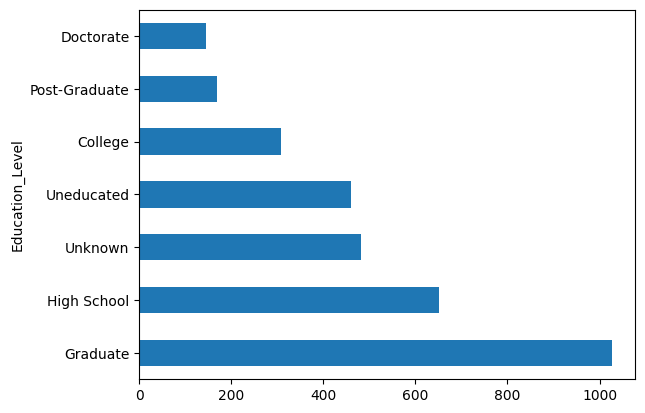

In [34]:
# Plot Education_Level bar graph
X_train['Education_Level'].value_counts().plot(kind='barh')

<Axes: ylabel='Education_Level_College,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown'>

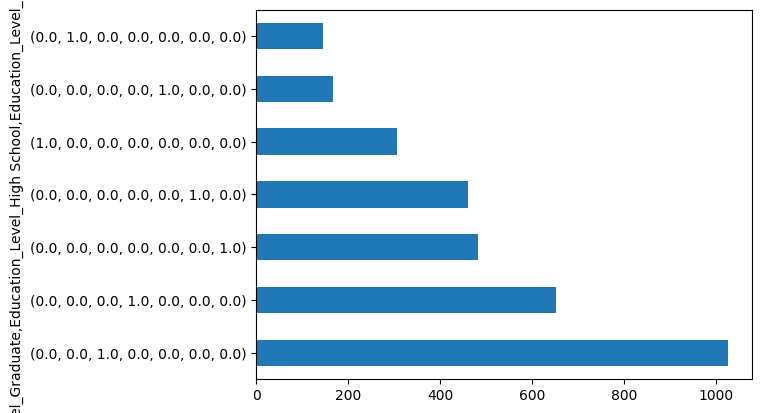

In [35]:
# Apply Education_Level one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore')
results = encoder.fit_transform(X_train[['Education_Level']])

# Plot preprocessed Education_Level bar graph
pd.DataFrame(results.toarray(), columns=encoder.get_feature_names_out()).value_counts().plot(kind='barh')

array([[<Axes: title={'center': 'Dependent_count'}>]], dtype=object)

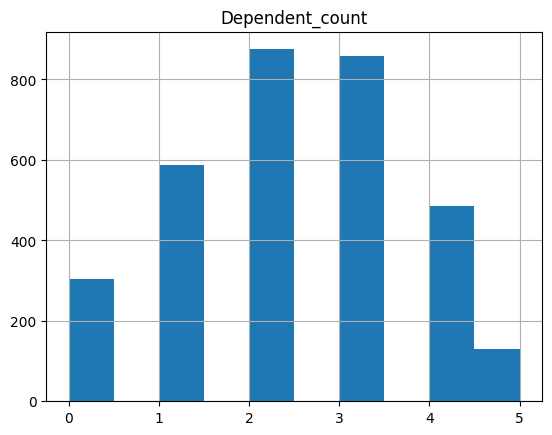

In [36]:
# Plot Dependent_count histogram
X_train[['Dependent_count']].hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

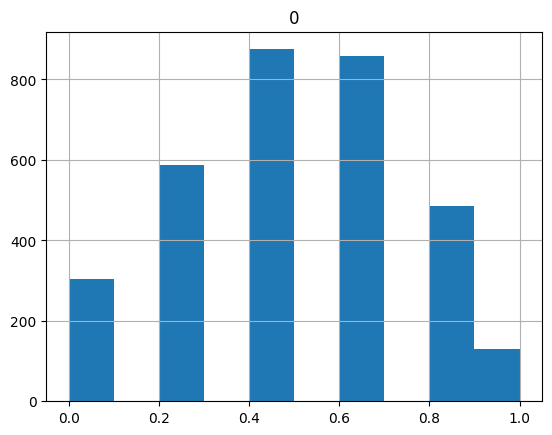

In [37]:
# Apply Dependent_count minmax scaling
results = MinMaxScaler().fit_transform(X_train[['Dependent_count']])

# Plot preprocessed Customer_Age histogram
pd.DataFrame(results).hist()


array([[<Axes: title={'center': 'Months_Inactive_12_mon'}>]], dtype=object)

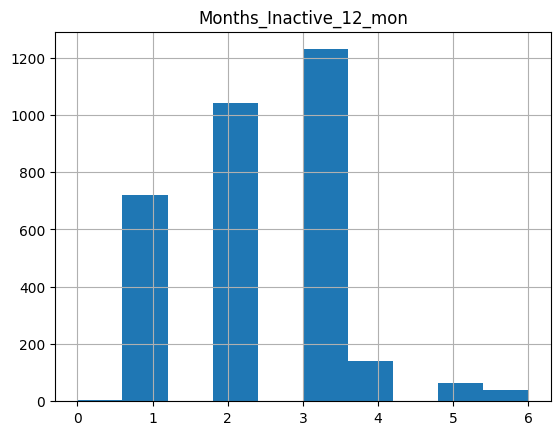

In [38]:
# Plot Months_Inactive_12_mon histogram
X_train[['Months_Inactive_12_mon']].hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

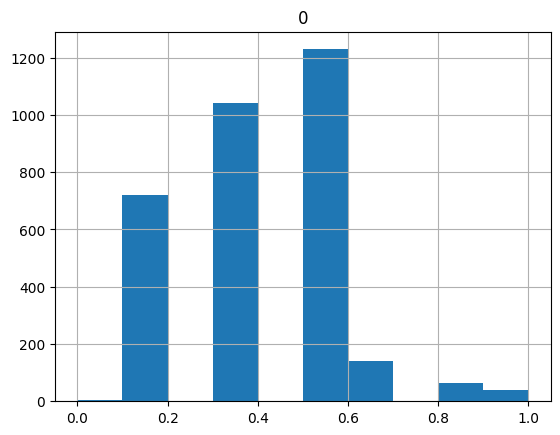

In [39]:
# Apply Months_Inactive_12_mon minmax scaling
results = MinMaxScaler().fit_transform(X_train[['Months_Inactive_12_mon']])

# Plot preprocessed Customer_Age histogram
pd.DataFrame(results).hist()


array([[<Axes: title={'center': 'Total_Trans_Amt'}>]], dtype=object)

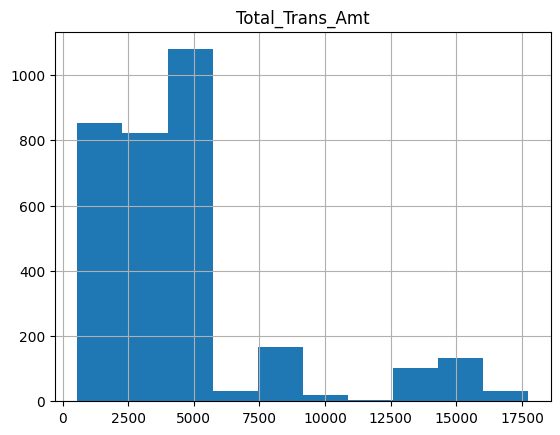

In [40]:
# Plot Total_Trans_Amt histogram
X_train[['Total_Trans_Amt']].hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

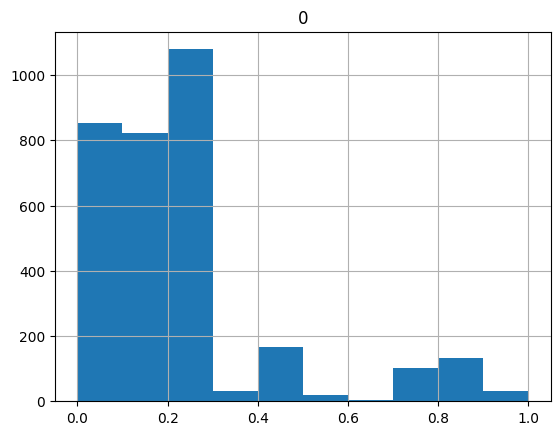

In [41]:
# Apply Total_Trans_Amt minmax scaling
results = MinMaxScaler().fit_transform(X_train[['Total_Trans_Amt']])

# Plot preprocessed Customer_Age histogram
pd.DataFrame(results).hist()
